<div style="text-align: center;">

  <!-- Logotipo -->
  <img src="img/logouesc.png" alt="UESC" style="width: 60px; display: block; margin: 0 auto 5px auto;">

  <!-- Cabeçalho -->
  <div style="font-size: 20px;"><strong>UNIVERSIDADE ESTADUAL DE SANTA CRUZ - UESC</strong></div>
  <div style="font-size: 18px;">DEPARTAMENTO DE ENGENHARIAS E COMPUTAÇÃO</div>
  <div style="font-size: 18px;">ENGENHARIA QUÍMICA</div>

  <hr style="margin: 20px 0; border: 1px solid #0074B7;">

  <!-- Título do Trabalho -->
  <div style="font-size: 22px; font-weight: bold; margin-bottom: 10px;">Engenharia Auxiliada por Computador</div>
  <div style="font-size: 20px; font-weight: bold; margin-bottom: 10px;">Dimensionamento de Vasos de Pressão: Resolução Passo a Passo</div>

  <!-- Autor e orientador -->
  <div style="font-size: 18px;">Prof. Dr. E.R.Edwards</div>

<hr style="margin: 20px 0; border: 1px solid #0074B7;">
  <!-- Data -->
<!-- <div style="font-size: 16px; margin-top: 15px;">Ilhéus - BA, Abril de 2025</div> -->
</div>

<div style="background-color: #e6f2ff; border-left: 6px solid #0074B7; padding: 10px; font-size: 16px;"><strong>Introdução ao Dimensionamento de Vasos de Pressão.</strong> 
</div>

Neste material, desenvolveremos o **dimensionamento de vasos de pressão passo a passo**, utilizando o Python como uma **ferramenta de cálculo direto, transparente e verificável**.

A proposta não é utilizar a programação como uma ``caixa-preta'' para simplesmente obter resultados numéricos. Ao contrário, cada cálculo será construído da mesma forma que seria desenvolvido manualmente: **identificando os dados de entrada, definindo as variáveis, escrevendo as equações, verificando as unidades de medida e interpretando fisicamente os resultados obtidos**.

O desenvolvimento computacional seguirá a mesma fundamentação teórica apresentada na apostila da disciplina. Dessa forma, será possível estabelecer uma ligação direta entre o **problema físico**, o **modelo matemático**, o **cálculo de engenharia** e sua **implementação em Python**.

Ao longo da atividade, seguiremos a sequência:

> **Compreender → Calcular → Programar → Modelar (CAD) → Analisar → Decidir**

Essa sequência representa uma ideia fundamental da **Engenharia Auxiliada por Computador**: o computador não substitui o conhecimento do engenheiro. Python e SolidWorks são ferramentas utilizadas para ampliar sua capacidade de **calcular, modelar, analisar alternativas e tomar decisões de engenharia tecnicamente fundamentadas**.

__Da interpretação física ao cálculo__

A figura a seguir representa o ponto de partida para o dimensionamento que será desenvolvido neste notebook. Antes de escrever qualquer linha de código, é necessário compreender **qual fenômeno físico está sendo modelado** e como esse fenômeno é transformado em uma equação de engenharia.

Quando o vaso está submetido a uma pressão interna \(P\), essa pressão atua continuamente sobre a superfície interna do casco. Se imaginarmos um **corte longitudinal** dividindo o cilindro em duas metades, a pressão tende a afastá-las. A parede do vaso, por sua vez, deve resistir a essa separação.

O equilíbrio entre a **força produzida pela pressão interna** e a **força resistente desenvolvida pelo material da parede** conduz à expressão da tensão circunferencial:

$$\sigma_\theta=\frac{PD}{2t}=\frac{PR}{t}$$


Essa relação mostra imediatamente uma característica fundamental do projeto: a tensão desenvolvida na parede depende da **pressão interna**, do **diâmetro do vaso** e da **espessura do casco**.

Nos cálculos a seguir, partiremos exatamente dessa interpretação física e avançaremos progressivamente para o dimensionamento. Primeiro definiremos os **dados de projeto**; em seguida, realizaremos os **cálculos passo a passo em Python** e, posteriormente, analisaremos como as diferentes variáveis influenciam a espessura necessária e as decisões de projeto.

Assim, antes de programar, devemos sempre lembrar:

> **o código não cria o modelo de engenharia; ele implementa computacionalmente um modelo que precisa ser compreendido primeiro.**

Vamos, portanto, começar pela definição dos dados necessários ao dimensionamento.

<img src="img/vaso-pressao-com-casco.png" alt="UESC" style="width: 700px; display: block; margin: 0 auto 5px auto;">
<p style="text-align: center;"><strong>Figura: Tensão circunferencial: corte longitudinal do casco e equilíbrio de forças.</strong></p>

__EXERCÍCIO 1 — Dimensionamento Básico do Casco__

A partir da interpretação física apresentada na figura anterior, vamos agora utilizar
as grandezas geométricas e de carregamento para determinar a espessura necessária
do casco.

Observe que manteremos a mesma notação utilizada na figura:

- ($P$) — pressão interna de projeto;
- ($D$) — diâmetro interno do vaso;
- ($R$) — raio interno do vaso, sendo ($R=D/2$);
- ($t$) — espessura da parede do casco.

Para o dimensionamento, serão acrescentados os parâmetros de projeto ($S$), ($E$) e
($CA$), conforme apresentado na fundamentação teórica da apostila.

__Dados do problema__

Considere um vaso de pressão com as seguintes condições:

- ($P = 1,5 \ \text{MPa}$)
- ($D = 800 \ \text{mm}$)
- ($S = 125 \ \text{MPa}$)
- ($E = 0,85$)
- ($CA = 2,5 \ \text{mm}$)

em que:

- ($S$) — tensão admissível do material;
- ($E$) — eficiência da junta soldada;
- ($CA$) — sobre-espessura de corrosão.

A expressão utilizada para o dimensionamento do casco é:

$ t_{\min}=\frac{P R}{S E - 0,6P}+CA $

Podemos separar o cálculo em duas etapas.

A espessura necessária para resistir à pressão interna é:

$ t_P = \frac{P R}{S E - 0,6P} $

e, acrescentando a sobre-espessura de corrosão:

$ t_{\min}=t_P+C $

__Determinar__

1. O raio interno do vaso, ($R$);
2. A espessura necessária para resistir à pressão interna, ($t_P$);
3. A espessura mínima requerida, ($t_{\min}$);
4. A espessura comercial a ser adotada entre as alternativas
   ($6, \ 8,\ 10,\ 12,\ 16\ \text{mm}$);
5. O diâmetro externo correspondente, ($D_o$).

__EXERCÍCIO 1 — Dimensionamento Básico do Casco__

__Enunciado__

Considere o projeto de um vaso de pressão constituído por um __casco cilíndrico submetido à pressão interna__. Conforme apresentado na figura anterior, a pressão $P$ atua sobre a superfície interna do casco e produz esforços que devem ser resistidos pela parede do equipamento.

Para o dimensionamento do casco, são conhecidos os seguintes dados de projeto:

- pressão interna de projeto: $P = 1{,}5\ \text{MPa}$;
- diâmetro interno do vaso: $D = 800\ \text{mm}$;
- tensão admissível do material: $S = 125\ \text{MPa}$;
- eficiência da junta soldada: $E = 0{,}85$;
- sobre-espessura de corrosão: $CA = 2{,}5\ \text{mm}$.

Como mostrado na figura anterior, o raio interno $R$ está relacionado ao diâmetro interno $D$ por:

$$
R = \frac{D}{2}
$$

Para as condições estabelecidas neste exercício, a espessura necessária para resistir à pressão interna será determinada por:

$$
t_P =
\frac{P R}{S E - 0{,}6P}
$$

em que $t_P$ representa a **espessura necessária para resistir à pressão interna**, antes da consideração da sobre-espessura de corrosão.

Para tornar o desenvolvimento do cálculo completamente transparente, a expressão será inicialmente separada em numerador e denominador:

$$
\text{Numerador} = PR
$$

$$
\text{Denominador} = SE - 0{,}6P
$$

de modo que:

$$
t_P =
\frac{\text{Numerador}}{\text{Denominador}}
$$

Após a determinação de $t_P$, deve-se acrescentar a sobre-espessura de corrosão $CA$. Dessa forma, a espessura mínima requerida para o casco será:

$$
t_{\min} = t_P + CA
$$

Entretanto, a espessura calculada não corresponde necessariamente a uma espessura de chapa disponível comercialmente. Para este exercício, considere, hipoteticamente, as seguintes espessuras comerciais:

$$
6,\quad 8,\quad 10,\quad 12,\quad 16\ \text{mm}
$$

A espessura comercial adotada, representada por $t_{\mathrm{adot}}$, deverá ser a **menor espessura disponível que seja igual ou superior à espessura mínima requerida** $t_{\min}$.

Após a escolha de $t_{\mathrm{adot}}$, o diâmetro externo do vaso poderá ser determinado considerando a espessura da parede nos dois lados do casco:

$$
D_o = D + 2t_{\mathrm{adot}}
$$

__Determine__:

1. O raio interno do vaso, $R$;

2. O numerador $PR$ da equação utilizada para o cálculo da espessura;

3. O denominador $SE - 0{,}6P$ da equação utilizada para o cálculo da espessura;

4. A espessura necessária para resistir à pressão interna, $t_P$;

5. A espessura mínima requerida após a inclusão da sobre-espessura de corrosão, $t_{\min}$;

6. A espessura comercial $t_{\mathrm{adot}}$ a ser utilizada na fabricação, considerando as alternativas disponíveis;

7. O diâmetro externo correspondente, $D_o$.

__Análise de engenharia__

Ao final dos cálculos, compare os valores obtidos para $t_P$, $t_{\min}$ e $t_{\mathrm{adot}}$ e explique por que essas três grandezas representam etapas diferentes do processo de dimensionamento do casco.

In [15]:
# =====================================================================
# EXERCÍCIO 1 — DADOS DE ENTRADA DO PROBLEMA
# =====================================================================

# Pressão interna de projeto [MPa]
P = 1.5

# Diâmetro interno do casco [mm]
D = 800.0

# Tensão admissível do material [MPa]
S = 125.0

# Eficiência da junta soldada [-]
E = 0.85

# Sobreespessura de corrosão [mm]
CA = 2.5

# Apresentação dos dados de entrada
print("DADOS DE ENTRADA")
print("-" * 45)
print("Pressão interna de projeto (P):", P, "MPa")
print("Diâmetro interno do casco (D):", D, "mm")
print("Tensão admissível do material (S):", S, "MPa")
print("Eficiência da junta soldada (E):", E)
print("Sobreespessura de corrosão (CA):", CA, "mm")

DADOS DE ENTRADA
---------------------------------------------
Pressão interna de projeto (P): 1.5 MPa
Diâmetro interno do casco (D): 800.0 mm
Tensão admissível do material (S): 125.0 MPa
Eficiência da junta soldada (E): 0.85
Sobreespessura de corrosão (CA): 2.5 mm


In [16]:
# ---------------------------------------------------------------------
# Item 1: Cálculo do raio interno (R)
# ---------------------------------------------------------------------

# O raio interno corresponde à metade do diâmetro interno do casco
R = D / 2

print("1) Raio interno (R):", R, "mm")

1) Raio interno (R): 400.0 mm


In [17]:
# ---------------------------------------------------------------------
# Itens 2, 3 e 4: Cálculo da espessura necessária para pressão (t_P)
# ---------------------------------------------------------------------

# Numerador da equação: P * R
numerador = P * R

# Denominador da equação: S * E - 0.6 * P
denominador = S * E - 0.6 * P

# Espessura necessária para resistir à pressão interna
t_P = numerador / denominador

print("2) Numerador (P * R):", round(numerador, 3), "MPa.mm")
print("3) Denominador (S * E - 0.6 * P):", round(denominador, 3), "MPa")
print("4) Espessura para pressão (t_P):", round(t_P, 3), "mm")

2) Numerador (P * R): 600.0 MPa.mm
3) Denominador (S * E - 0.6 * P): 105.35 MPa
4) Espessura para pressão (t_P): 5.695 mm


In [18]:
# ---------------------------------------------------------------------
# Item 5: Cálculo da espessura mínima requerida (t_min)
# ---------------------------------------------------------------------

# A espessura mínima requerida corresponde à espessura necessária
# para resistir à pressão interna acrescida da sobre-espessura
# de corrosão (CA)
t_min = t_P + CA

print("5) Espessura mínima requerida (t_min):", round(t_min, 3), "mm")

5) Espessura mínima requerida (t_min): 8.195 mm


In [19]:
# ---------------------------------------------------------------------
# Item 6: Seleção da espessura comercial adotada (t_adot)
# ---------------------------------------------------------------------

# Espessuras comerciais hipoteticamente disponíveis:
# 6, 8, 10, 12 e 16 mm
#
# Como a espessura mínima requerida é:
# t_min = 8.195 mm
#
# A chapa de 8 mm não atende ao valor mínimo requerido.
# Portanto, deve-se selecionar a próxima espessura comercial disponível.

t_adot = 10.0  # mm

print("6) Espessura comercial adotada (t_adot):", t_adot, "mm")

6) Espessura comercial adotada (t_adot): 10.0 mm


__7. Cálculo do diâmetro externo__

Após a definição da espessura comercial $t_{\mathrm{adot}}$, podemos determinar o diâmetro externo do casco. Como a espessura da parede está presente nos dois lados do vaso, o diâmetro externo é dado por:

$$
D_o = D + 2t_{\mathrm{adot}}
$$

Substituindo os valores:

$$
D_o = 800 + 2(10)
$$

$$
D_o = 820\ \text{mm}
$$

Portanto:

$$
\boxed{D_o = 820\ \text{mm}}
$$

In [20]:
# ---------------------------------------------------------------------
# Item 7: Cálculo do diâmetro externo correspondente (D_o)
# ---------------------------------------------------------------------

# O diâmetro externo corresponde ao diâmetro interno acrescido
# de duas vezes a espessura comercial adotada, pois a espessura
# da parede está presente nos dois lados do casco.

D_o = D + 2 * t_adot

print("7) Diâmetro externo (D_o):", D_o, "mm")

7) Diâmetro externo (D_o): 820.0 mm


__EXERCÍCIO 2 — Influência da Pressão no Dimensionamento do Casco__

__Enunciado__

No exercício anterior, foi realizado o dimensionamento do casco para uma única condição de pressão interna. Entretanto, durante o projeto de um vaso de pressão, é importante compreender como alterações nas condições de operação podem influenciar as dimensões necessárias para garantir sua integridade estrutural.

Neste exercício, será analisada especificamente a **influência da pressão interna de projeto $P$ sobre a espessura mínima requerida do casco**, mantendo-se constantes as demais características do vaso.

Considere um vaso de pressão cilíndrico com os seguintes dados de projeto:

- diâmetro interno do casco: $D = 1000\ \text{mm}$;
- tensão admissível do material: $S = 140\ \text{MPa}$;
- eficiência da junta soldada: $E = 0{,}90$;
- sobre-espessura de corrosão: $CA = 3{,}0\ \text{mm}$.

O raio interno $R$ deverá ser determinado a partir do diâmetro interno $D$:

$$
R = \frac{D}{2}
$$

Para avaliar a influência da pressão, considere os seguintes valores de pressão interna de projeto:

$$
P =
[0{,}5;\ 1{,}0;\ 1{,}5;\ 2{,}0;\ 2{,}5;\ 3{,}0]\ \text{MPa}
$$

Para cada valor de pressão, a espessura necessária para resistir à pressão interna deverá ser calculada por:

$$
t_P =
\frac{PR}{SE-0{,}6P}
$$

Em seguida, deverá ser acrescentada a sobre-espessura de corrosão $CA$, obtendo-se:

$$
t_{\min}=t_P+CA
$$

__Determine__:

1. O raio interno do vaso, $R$;

2. A espessura necessária para resistir à pressão interna, $t_P$, para cada valor de $P$;

3. A espessura mínima requerida, $t_{\min}$, para cada valor de $P$;

4. Uma tabela relacionando os valores de $P$, $t_P$ e $t_{\min}$;

5. Um gráfico de $t_{\min}$ em função da pressão interna de projeto $P$;

6. O comportamento da espessura mínima requerida à medida que a pressão interna aumenta;

7. As consequências do aumento da espessura do casco sobre a quantidade de material, a massa do equipamento e seu custo de fabricação.

In [21]:
# =====================================================================
# EXERCÍCIO 2 — DADOS DE ENTRADA DO PROBLEMA
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# Diâmetro interno do casco [mm]
D = 1000.0

# Tensão admissível do material [MPa]
S = 140.0

# Eficiência da junta soldada [-]
E = 0.90

# Sobreespessura de corrosão [mm]
CA = 3.0

# Valores de pressão interna de projeto analisados [MPa]
P = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

# Apresentação dos dados de entrada
print("DADOS DE ENTRADA")
print("-" * 55)
print("Diâmetro interno do casco (D):", D, "mm")
print("Tensão admissível do material (S):", S, "MPa")
print("Eficiência da junta soldada (E):", E)
print("Sobreespessura de corrosão (CA):", CA, "mm")
print("Pressões internas analisadas (P):", P, "MPa")

DADOS DE ENTRADA
-------------------------------------------------------
Diâmetro interno do casco (D): 1000.0 mm
Tensão admissível do material (S): 140.0 MPa
Eficiência da junta soldada (E): 0.9
Sobreespessura de corrosão (CA): 3.0 mm
Pressões internas analisadas (P): [0.5 1.  1.5 2.  2.5 3. ] MPa


In [22]:
# ---------------------------------------------------------------------
# Item 1: Cálculo do raio interno (R)
# ---------------------------------------------------------------------

# O raio interno corresponde à metade do diâmetro interno do casco
R = D / 2

print("1) Raio interno (R):", R, "mm")

1) Raio interno (R): 500.0 mm


In [23]:
# ---------------------------------------------------------------------
# Item 2: Cálculo da espessura necessária para pressão (t_P)
# ---------------------------------------------------------------------

# Para cada valor de pressão interna P, calcula-se a espessura
# necessária para resistir à pressão.
#
# Fórmula:
# t_P = (P * R) / (S * E - 0.6 * P)

t_P = (P * R) / (S * E - 0.6 * P)

# Apresentação dos resultados
print("2) ESPESSURA NECESSÁRIA PARA PRESSÃO (t_P)")
print("-" * 45)

for i in range(len(P)):
    print(
        "P =", P[i], "MPa",
        " -> t_P =", round(t_P[i], 3), "mm"
    )

2) ESPESSURA NECESSÁRIA PARA PRESSÃO (t_P)
---------------------------------------------
P = 0.5 MPa  -> t_P = 1.989 mm
P = 1.0 MPa  -> t_P = 3.987 mm
P = 1.5 MPa  -> t_P = 5.995 mm
P = 2.0 MPa  -> t_P = 8.013 mm
P = 2.5 MPa  -> t_P = 10.04 mm
P = 3.0 MPa  -> t_P = 12.077 mm


In [24]:
# ---------------------------------------------------------------------
# Item 3: Cálculo da espessura mínima requerida (t_min)
# ---------------------------------------------------------------------

# Para cada valor de pressão, a espessura mínima requerida corresponde
# à espessura necessária para resistir à pressão interna acrescida
# da sobre-espessura de corrosão (CA).
#
# Fórmula:
# t_min = t_P + CA

t_min = t_P + CA

# Apresentação dos resultados
print("3) ESPESSURA MÍNIMA REQUERIDA (t_min)")
print("-" * 55)

for i in range(len(P)):
    print(
        "P =", P[i], "MPa",
        " -> t_P =", round(t_P[i], 3), "mm",
        " -> t_min =", round(t_min[i], 3), "mm"
    )

3) ESPESSURA MÍNIMA REQUERIDA (t_min)
-------------------------------------------------------
P = 0.5 MPa  -> t_P = 1.989 mm  -> t_min = 4.989 mm
P = 1.0 MPa  -> t_P = 3.987 mm  -> t_min = 6.987 mm
P = 1.5 MPa  -> t_P = 5.995 mm  -> t_min = 8.995 mm
P = 2.0 MPa  -> t_P = 8.013 mm  -> t_min = 11.013 mm
P = 2.5 MPa  -> t_P = 10.04 mm  -> t_min = 13.04 mm
P = 3.0 MPa  -> t_P = 12.077 mm  -> t_min = 15.077 mm


In [25]:
# ---------------------------------------------------------------------
# Item 4: Organização dos resultados em tabela
# ---------------------------------------------------------------------

# Os valores calculados para P, t_P e t_min são apresentados
# em uma tabela para facilitar a comparação entre as diferentes
# condições de pressão analisadas.

print("4) TABELA DE RESULTADOS")
print("-" * 53)
print(" P (MPa)  |   t_P (mm)   |   t_min (mm)")
print("-" * 53)

for i in range(len(P)):
    print(
        f"   {P[i]:.1f}    |"
        f"     {t_P[i]:.3f}    |"
        f"      {t_min[i]:.3f}"
    )

print("-" * 53)

4) TABELA DE RESULTADOS
-----------------------------------------------------
 P (MPa)  |   t_P (mm)   |   t_min (mm)
-----------------------------------------------------
   0.5    |     1.989    |      4.989
   1.0    |     3.987    |      6.987
   1.5    |     5.995    |      8.995
   2.0    |     8.013    |      11.013
   2.5    |     10.040    |      13.040
   3.0    |     12.077    |      15.077
-----------------------------------------------------


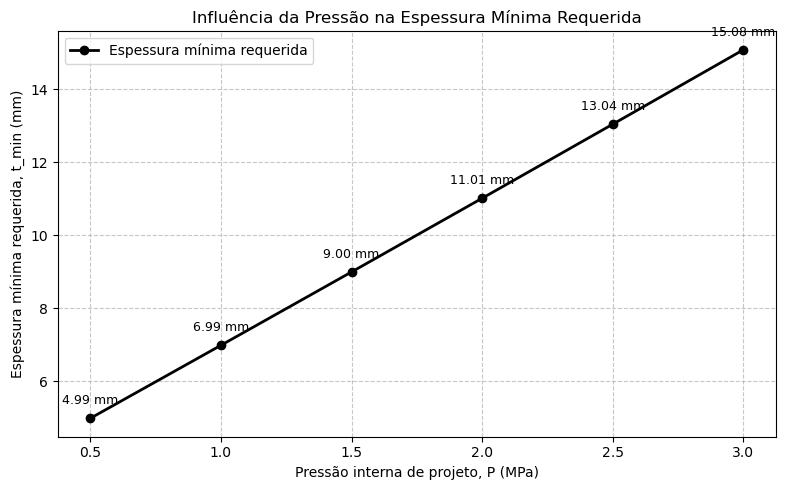

In [26]:
# ---------------------------------------------------------------------
# Item 5: Gráfico da espessura mínima requerida em função da pressão
# ---------------------------------------------------------------------

# Construção da figura
plt.figure(figsize=(8, 5))

# Curva da espessura mínima requerida em função da pressão
plt.plot(
    P,
    t_min,
    color="black",
    marker="o",
    linewidth=2,
    label="Espessura mínima requerida"
)

# Identificação dos valores de t_min em cada ponto
for i in range(len(P)):
    plt.annotate(
        f"{t_min[i]:.2f} mm",
        (P[i], t_min[i]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# Identificação dos eixos e do gráfico
plt.title("Influência da Pressão na Espessura Mínima Requerida")
plt.xlabel("Pressão interna de projeto, P (MPa)")
plt.ylabel("Espessura mínima requerida, t_min (mm)")

# Elementos auxiliares
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()

# Exibição do gráfico
plt.show()

__Interpretação de Engenharia dos Resultados__

Os resultados obtidos mostram claramente a influência da pressão interna de projeto $P$ sobre a espessura mínima requerida $t_{\min}$ do casco.

Para a menor pressão analisada, $P = 0{,}5\ \text{MPa}$, obteve-se:

$$
t_{\min}=4{,}989\ \text{mm}
$$

Quando a pressão é elevada para $P = 3{,}0\ \text{MPa}$, a espessura mínima requerida passa para:

$$
t_{\min}=15{,}077\ \text{mm}
$$

Portanto, mantendo constantes o diâmetro do vaso, a tensão admissível do material, a eficiência da junta soldada e a sobre-espessura de corrosão, o aumento da pressão interna exige o aumento da espessura da parede do casco.

Esse comportamento pode ser compreendido diretamente pela equação utilizada no dimensionamento:

$$
t_P=
\frac{PR}{SE-0{,}6P}
$$

A pressão $P$ aparece tanto no numerador quanto no denominador da expressão. Quando $P$ aumenta, o numerador $PR$ aumenta e, simultaneamente, o termo $SE-0{,}6P$ presente no denominador diminui. Esses dois efeitos contribuem para o aumento da espessura necessária $t_P$.

No intervalo de pressões analisado, o gráfico apresenta um comportamento visualmente próximo de uma reta. Entretanto, a relação matemática entre $P$ e $t_P$ não é rigorosamente linear, pois a pressão também está presente no denominador da equação. Dessa forma, a influência da pressão torna-se progressivamente mais significativa à medida que seu valor aumenta.

Outro aspecto importante pode ser observado na relação:

$$
t_{\min}=t_P+CA
$$

Como a sobre-espessura de corrosão foi mantida constante em:

$$
CA=3{,}0\ \text{mm}
$$

todos os valores de $t_{\min}$ permanecem exatamente $3{,}0$ mm acima dos respectivos valores de $t_P$. Nesse exercício, portanto, o aumento observado em $t_{\min}$ é consequência da variação da pressão interna, e não de uma alteração da sobre-espessura de corrosão.

__Consequências para o projeto do vaso__

O aumento da espessura não representa apenas uma alteração geométrica. Ele produz consequências diretas sobre outras características do equipamento.

Para um mesmo diâmetro e comprimento de casco, uma parede mais espessa exige maior volume de material. Consequentemente:

$$
P\uparrow
\quad\Longrightarrow\quad
t_{\min}\uparrow
\quad\Longrightarrow\quad
V_{\mathrm{material}}\uparrow
\quad\Longrightarrow\quad
m\uparrow
$$

O aumento da quantidade de material tende também a elevar o custo do equipamento. Além do maior consumo de matéria-prima, chapas mais espessas podem modificar as condições de fabricação, soldagem, movimentação, transporte e suportação do vaso.

Assim, uma variável inicialmente associada à condição de operação — a pressão interna — produz consequências que se propagam por diferentes etapas do projeto:

$$
\boxed{
\text{Pressão}
\rightarrow
\text{Espessura}
\rightarrow
\text{Quantidade de material}
\rightarrow
\text{Massa}
\rightarrow
\text{Fabricação}
\rightarrow
\text{Custo}
}
$$

Essa análise evidencia uma característica fundamental da Engenharia Auxiliada por Computador: o objetivo não é apenas obter um valor numérico para a espessura. O engenheiro deve compreender como uma alteração nas condições de projeto modifica a geometria do equipamento e quais consequências técnicas e econômicas decorrem dessa alteração.

> **O cálculo fornece a espessura necessária. A engenharia exige compreender as consequências dessa espessura sobre o equipamento como um todo.**

<div style="text-align: center; font-size: 12px; color: gray; margin-top: 40px;">
  Este notebook foi desenvolvido no âmbito do Grupo de Pesquisas em Modelagem Computacional da UESC.<br>
  Todos os direitos reservados © 2025
</div>